# Phase 4 — Convolutional Neural Networks (CNNs)

Phase 3's MLP flattened every image into a 784-length vector before the
first `Linear` layer — which throws away all 2D structure. A `Linear` layer
has no notion that pixel `(5, 5)` is *next to* pixel `(5, 6)`; they're just
two unrelated numbers in a long vector.

A **Convolutional Neural Network** fixes this. Instead of connecting every
input pixel to every output neuron, a small filter (e.g. 3x3) slides across
the image and looks at local neighborhoods, learning to detect patterns
like edges and curves — and the *same* filter is reused at every position,
which also means far fewer parameters than a fully-connected layer would
need for the same input size.

| Term | Meaning |
|---|---|
| `in_channels` | channels in the input (1 = grayscale, 3 = RGB) |
| `out_channels` | number of filters to learn; each produces its own output channel ("feature map") |
| `kernel_size` | size of each sliding filter, e.g. 3 -> a 3x3 window |
| `stride` | how many pixels the filter moves each step |
| `padding` | zero-pixels added around the border so filters can center on edge pixels too |
| `nn.MaxPool2d` | downsamples a feature map by taking the max value in each window |
| feature map | one `out_channel`'s worth of output — a 2D grid of "how strongly did this filter match, at each position" |

## Roadmap for this notebook
```
nn.Conv2d shapes (padding & stride) -> pooling -> a conv/pool stack, shape by shape
    -> building SimpleCNN -> training on MNIST -> comparing to the Phase 3 MLP
```


## Section 1 — `nn.Conv2d`: Sliding Filters Over an Image

Tensors flowing through a CNN keep the shape `(batch, channels, height, width)`.
`padding` and `stride` are what control how the spatial size (`height, width`)
changes after a convolution — everything else about the input is preserved.

In [1]:
import torch
import torch.nn as nn

torch.manual_seed(42)
image = torch.randn(1, 1, 28, 28)   # (batch=1, channels=1 grayscale, height=28, width=28)

# No padding: a 3x3 filter can't be centered on the outer border pixels,
# so the output shrinks: 28 - (kernel_size - 1) = 28 - 2 = 26
conv_no_pad = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=0)
print(f'padding=0 : {image.shape} -> {conv_no_pad(image).shape}   <- shrinks by (kernel_size - 1)')

# padding=1 adds a 1-pixel zero border, which exactly compensates a 3x3 filter:
# the spatial size (28x28) is preserved ("same" padding).
conv_same = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
print(f'padding=1 : {image.shape} -> {conv_same(image).shape}   <- spatial size preserved')

# stride=2 skips every other position, roughly halving height & width.
conv_stride2 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, stride=2, padding=1)
print(f'stride=2  : {image.shape} -> {conv_stride2(image).shape}   <- roughly halves height & width')

# out_channels = how many different filters to learn. Each learns its own
# pattern and produces its own output channel (its own feature map).
print(f'\nconv_same.weight.shape: {conv_same.weight.shape}   <- (out_channels, in_channels, kh, kw)')

padding=0 : torch.Size([1, 1, 28, 28]) -> torch.Size([1, 8, 26, 26])   <- shrinks by (kernel_size - 1)
padding=1 : torch.Size([1, 1, 28, 28]) -> torch.Size([1, 8, 28, 28])   <- spatial size preserved
stride=2  : torch.Size([1, 1, 28, 28]) -> torch.Size([1, 8, 14, 14])   <- roughly halves height & width

conv_same.weight.shape: torch.Size([8, 1, 3, 3])   <- (out_channels, in_channels, kh, kw)


## Section 2 — Pooling: Downsampling Feature Maps

`nn.MaxPool2d(kernel_size=2)` slides a non-overlapping 2x2 window over each
feature map and keeps only the max value in each window — halving height
and width while leaving the number of channels untouched. This shrinks the
computation for later layers and keeps the strongest activations.

In [2]:
features = conv_same(image)          # (1, 8, 28, 28), continuing from Section 1
pool = nn.MaxPool2d(kernel_size=2)   # default stride = kernel_size (non-overlapping windows)
pooled = pool(features)

print(f'before pooling                : {features.shape}')
print(f'after MaxPool2d(kernel_size=2): {pooled.shape}   <- halves height & width, channels unchanged')

before pooling                : torch.Size([1, 8, 28, 28])
after MaxPool2d(kernel_size=2): torch.Size([1, 8, 14, 14])   <- halves height & width, channels unchanged


## Section 3 — A Full Conv → Pool → Conv → Pool Stack

The typical CNN pattern stacks `Conv2d -> ReLU -> MaxPool2d` blocks, each
one shrinking the spatial size while (usually) growing the channel count —
trading "where exactly" for "what pattern, roughly where." Tracing the
shapes through two such blocks by hand shows exactly where the
`16 * 7 * 7` constant in Section 4's classifier comes from.

In [3]:
x = torch.randn(1, 1, 28, 28)
print(f'input             : {x.shape}')

x = nn.Conv2d(1, 8, kernel_size=3, padding=1)(x)
x = nn.ReLU()(x)
x = nn.MaxPool2d(2)(x)
print(f'after conv1+pool1 : {x.shape}   <- 28x28 -> 14x14, 1 -> 8 channels')

x = nn.Conv2d(8, 16, kernel_size=3, padding=1)(x)
x = nn.ReLU()(x)
x = nn.MaxPool2d(2)(x)
print(f'after conv2+pool2 : {x.shape}   <- 14x14 -> 7x7, 8 -> 16 channels')

x = x.view(x.size(0), -1)
print(f'flattened         : {x.shape}   <- 16 * 7 * 7 = {16 * 7 * 7}, ready for a Linear classifier head')

input             : torch.Size([1, 1, 28, 28])
after conv1+pool1 : torch.Size([1, 8, 14, 14])   <- 28x28 -> 14x14, 1 -> 8 channels
after conv2+pool2 : torch.Size([1, 16, 7, 7])   <- 14x14 -> 7x7, 8 -> 16 channels
flattened         : torch.Size([1, 784])   <- 16 * 7 * 7 = 784, ready for a Linear classifier head


## Section 4 — Building `SimpleCNN`

Two parts, same idea as `nn.Sequential` from Phase 3:
- **`features`** — the conv/pool stack from Section 3, which extracts spatial patterns and produces a `(batch, 16, 7, 7)` tensor
- **`classifier`** — a small `Linear` head, same as Phase 3's MLP, that maps the flattened features to 10 class logits

> **Watch out:** it's an easy mistake to compute the classifier's output but
> then `return` the wrong variable from `forward()` (e.g. the flattened
> features instead of the classifier's output). Since both are just tensors,
> Python won't complain — but training will silently fail with a shape
> mismatch against the loss function. Always double check `forward()`
> returns what you actually intended.

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(16 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, 10),   # raw logits, one per digit class
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)     # flatten (batch, 16, 7, 7) -> (batch, 16*7*7)
        return self.classifier(x)     # must return the classifier's output, not the flattened features

model = SimpleCNN()
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {n_params:,}')

sample = torch.randn(4, 1, 28, 28)   # a batch of 4 images
print(f'\nsample batch -> logits shape: {model(sample).shape}   <- (batch, num_classes)')

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=784, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=10, bias=True)
  )
)

Total trainable parameters: 52,138

sample batch -> logits shape: torch.Size([4, 10])   <- (batch, num_classes)


## Section 5 — Training on MNIST

Same recipe as the Phase 3 project (`MNIST` dataset, `DataLoader`,
`CrossEntropyLoss`, `Adam`, the standard training loop) with `SimpleCNN`
swapped in for the MLP — and the **same** epoch count, batch size, learning
rate, and optimizer, so the comparison in Section 6 is apples-to-apples.

Using device: mps


Epoch 1/5 | Avg Loss: 0.3132


Epoch 2/5 | Avg Loss: 0.0928


Epoch 3/5 | Avg Loss: 0.0667


Epoch 4/5 | Avg Loss: 0.0521


Epoch 5/5 | Avg Loss: 0.0428


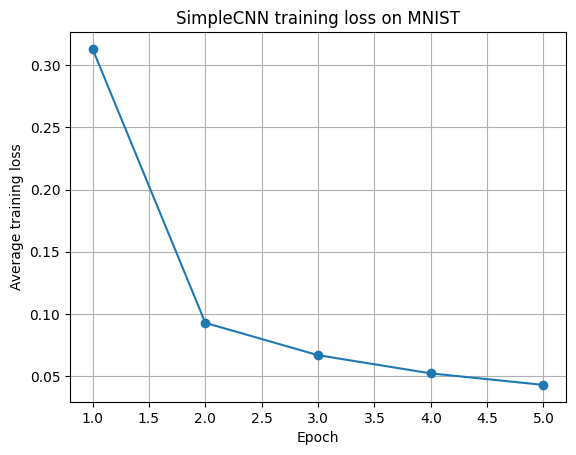

In [5]:
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

transform = transforms.ToTensor()
train_data = MNIST(root="data", train=True, download=True, transform=transform)
test_data = MNIST(root="data", train=False, download=True, transform=transform)   # held-out split

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

model = SimpleCNN().to(device)   # (): instantiate the class before moving it to a device
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5
loss_history = []

model.train()
for epoch in range(epochs):
    total_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)   # outputs, not output -- must match the variable just assigned
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch + 1}/{epochs} | Avg Loss: {avg_loss:.4f}")

plt.plot(range(1, epochs + 1), loss_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("SimpleCNN training loss on MNIST")
plt.grid(True)
plt.show()

## Section 6 — Evaluation & Comparison to the Phase 3 MLP

Same evaluation recipe as Phase 3: `model.eval()` + `torch.no_grad()`,
accuracy measured on the untouched test split.

In [6]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

cnn_accuracy = 100 * correct / total
print(f"SimpleCNN test accuracy: {cnn_accuracy:.2f}%  ({correct}/{total} correct)")

mlp_accuracy = 97.43     # from phase3_project.ipynb -- MLP, same epochs/batch_size/lr/optimizer
mlp_params = 109_386     # from phase3_project.ipynb

print(f"\n{'Model':<12}{'Params':>12}{'Test Accuracy':>16}")
print(f"{'MLP':<12}{mlp_params:>12,}{mlp_accuracy:>15.2f}%")
print(f"{'SimpleCNN':<12}{n_params:>12,}{cnn_accuracy:>15.2f}%")

SimpleCNN test accuracy: 98.50%  (9850/10000 correct)

Model             Params   Test Accuracy
MLP              109,386          97.43%
SimpleCNN         52,138          98.50%


## Section 7 — Visualize Predictions

Same visualization pattern as Phase 3: a grid of random test images with
the model's prediction vs the true label, green for correct and red for
wrong.

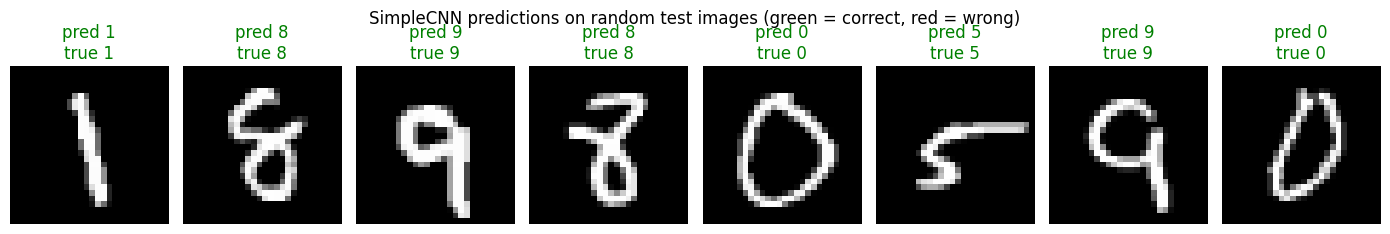

In [7]:
model.eval()
n_show = 8
indices = torch.randint(0, len(test_data), (n_show,))

fig, axes = plt.subplots(1, n_show, figsize=(14, 2.4))
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        image, true_label = test_data[idx]
        input_batch = image.unsqueeze(0).to(device)   # add batch dim -> (1, 1, 28, 28)
        predicted_label = model(input_batch).argmax(dim=1).item()

        ax.imshow(image.squeeze(), cmap="gray")
        is_correct = predicted_label == true_label
        ax.set_title(f"pred {predicted_label}\ntrue {true_label}",
                     color="green" if is_correct else "red")
        ax.axis("off")

plt.suptitle("SimpleCNN predictions on random test images (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Section 8 — Save & Reload the Model

Same `state_dict` pattern as Phase 3.

In [8]:
save_path = "simple_cnn_mnist.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

reloaded = SimpleCNN().to(device)
reloaded.load_state_dict(torch.load(save_path, map_location=device))
reloaded.eval()

with torch.no_grad():
    image, true_label = test_data[0]
    input_batch = image.unsqueeze(0).to(device)
    original_pred = model(input_batch).argmax(dim=1).item()
    reloaded_pred = reloaded(input_batch).argmax(dim=1).item()

print(f"Original model prediction : {original_pred}")
print(f"Reloaded model prediction : {reloaded_pred}   (should match)")

Model saved to simple_cnn_mnist.pth
Original model prediction : 7
Reloaded model prediction : 7   (should match)


## Phase 4 Summary

```
Convolution:
  nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
    in_channels   -> channels of the input (1 grayscale, 3 RGB)
    out_channels  -> number of learned filters = number of output feature maps
    padding=(kernel_size-1)//2   -> keeps spatial size unchanged ("same" padding, odd kernel)
    stride > 1                   -> downsamples while convolving

Pooling:
  nn.MaxPool2d(kernel_size)  -> downsamples each feature map, channels unchanged

Typical CNN block:
  Conv2d -> ReLU -> MaxPool2d   (repeated, channels usually grow as spatial size shrinks)
  ... -> x.view(x.size(0), -1) -> Linear classifier head -> logits

Common Pitfalls (all present in the original buggy notebook):
  - SimpleCNN.to(device)         -> forgot to instantiate: SimpleCNN().to(device)
  - loss_fn(output, labels)      -> typo'd variable name, doesn't match `outputs = model(images)`
  - return x  (in forward)       -> returned the flattened features, not self.classifier(x)
  - device = "cuda" if ... else "cpu"   -> missing the mps branch (misses Apple Silicon GPUs)

Result on MNIST (5 epochs, batch_size=64, lr=0.001, Adam -- identical to the Phase 3 MLP):
  MLP (Phase 3)        ~109k params  ->  97.43% test accuracy
  SimpleCNN (this notebook)          ->  see Section 6 for the exact numbers

Why the CNN tends to win: convolution's weight sharing (the same small
filter reused at every position) is a much better match for image
structure than a fully-connected layer, usually for a comparable or even
smaller parameter budget.
```